## Import Data and Visualization:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the provided data file:
file_path = '/content/overall jet fuel 2008-2016.csv'
fuel_data = pd.read_csv(file_path, header=None)
fuel_data.columns = ['Date', 'Fuel_Consumption']
fuel_data['Date'] = pd.to_datetime(fuel_data['Date'])
fuel_data = fuel_data.sort_values(by='Date')
fuel_data.set_index('Date', inplace=True)
fuel_data = pd.DataFrame(fuel_data)
# Display the rows of the data to understand its structure:
fuel_data.head()

,Fuel_Consumption
Date,
2008-05-24,320001.000000
2008-05-25,320001.826375
2008-05-26,320002.969334
2008-05-27,320003.513974
2008-05-28,320004.112301


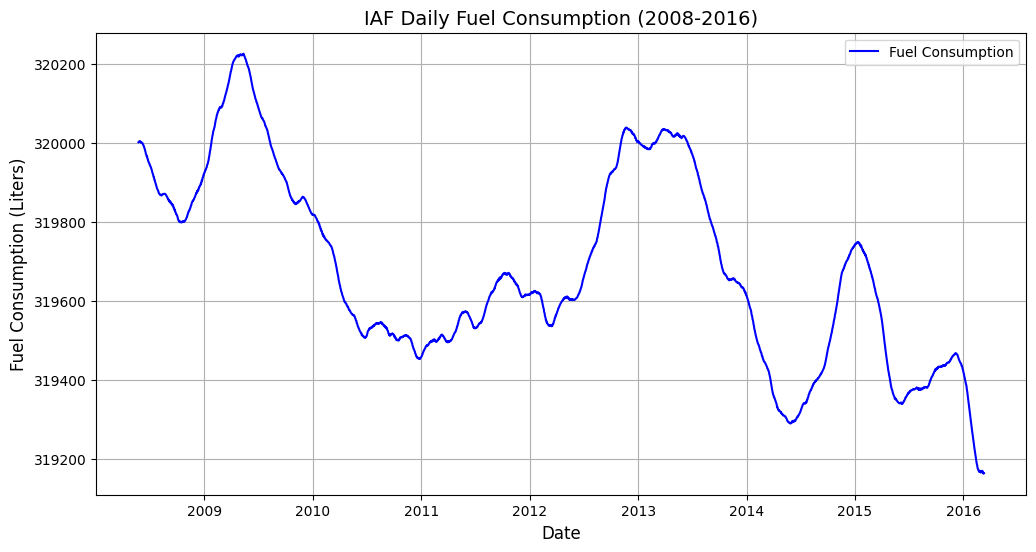

In [4]:
# Plot the fuel consumption time series
plt.figure(figsize=(12, 6))
plt.plot(fuel_data, label="Fuel Consumption", color='blue')
plt.title("IAF Daily Fuel Consumption (2008-2016)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Fuel Consumption (Liters)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Test stationarity:

From the graph, the data does not appear to be stationary. Here’s why:

1. Visual Trend:
There seems to be a subtle downward trend over time. Stationary data should not exhibit trends or shifts in its mean over time.

2. Fluctuations (Variance):
The amplitude of fluctuations appears to remain relatively stable, suggesting that variance might not be an issue. However, the presence of trends suggests that the mean is not constant.

3. Stationarity Check:
While visual inspection gives a clue, a formal test like the Augmented Dickey-Fuller (ADF) test is necessary to confirm stationarity. If the test statistic is greater than the critical values (or the p-value is >0.05), the data is non-stationary.

In [4]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries, cutoff = 0.01):
    #Perform Dickey-Fuller test:
    # H_0 in adfuller is unit root exists (Non-Stationary)
    print ('Results of Dickey-Fuller Test:')
    pvalue = adfuller(timeseries)[1]
    if pvalue < cutoff:
        print('p-value = '+ str(pvalue) + ' The series '+ timeseries.name + ' is likely stationary.')
    else:
        print('p-value = '+ str(pvalue) + ' The series '+ timeseries.name + ' is likely non-stationary.')

test_stationarity(fuel_data["Fuel_Consumption"])

Results of Dickey-Fuller Test:
p-value = 0.18103364532670269 The series Fuel_Consumption is likely non-stationary.


## Conclusion: The series is not stationary and we need to do differencing.   


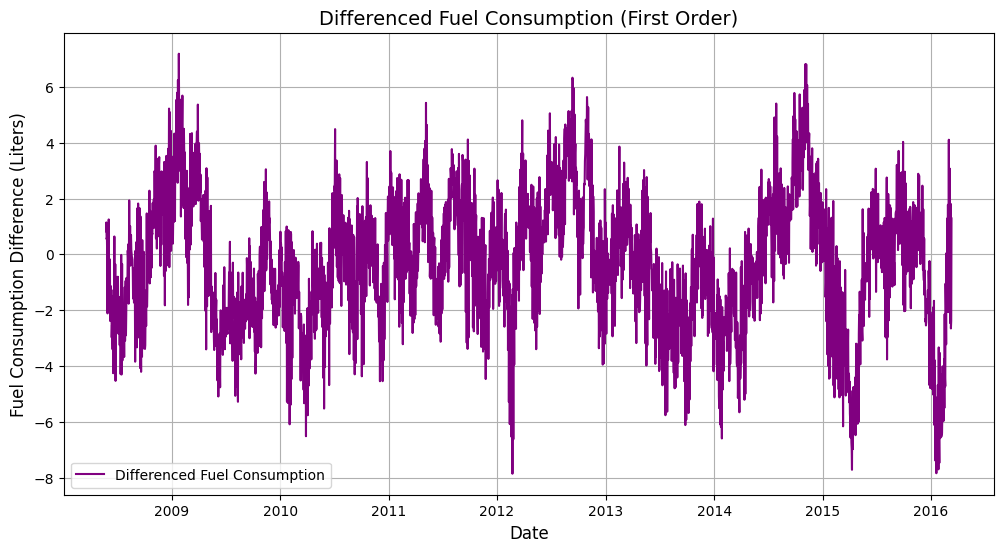

In [5]:
# Compute the differenced series
fuel_diff = fuel_data['Fuel_Consumption'].diff().dropna()

# Plot the differenced series
plt.figure(figsize=(12, 6))
plt.plot(fuel_diff, color='purple', label='Differenced Fuel Consumption')
plt.title('Differenced Fuel Consumption (First Order)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Fuel Consumption Difference (Liters)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


In [8]:
dif_res = adfuller(fuel_diff)
print('ADF Statistic: %f' % dif_res[0])
print("p-value: %f" % dif_res[1])
for key,value in dif_res[4].items():
  print(str(key) + ":" + str(value))

ADF Statistic: -4.802629
p-value: 0.000054
1%:-3.432652220947594
5%:-2.862557162935532
10%:-2.5673114660713336


## After one differencing the series visually stationary and according to ADF test is stationary (p_value < a and ADF statistic < critical value). Now, we can predict with ARIMA model the 20.10.15.

## ARIMA model:

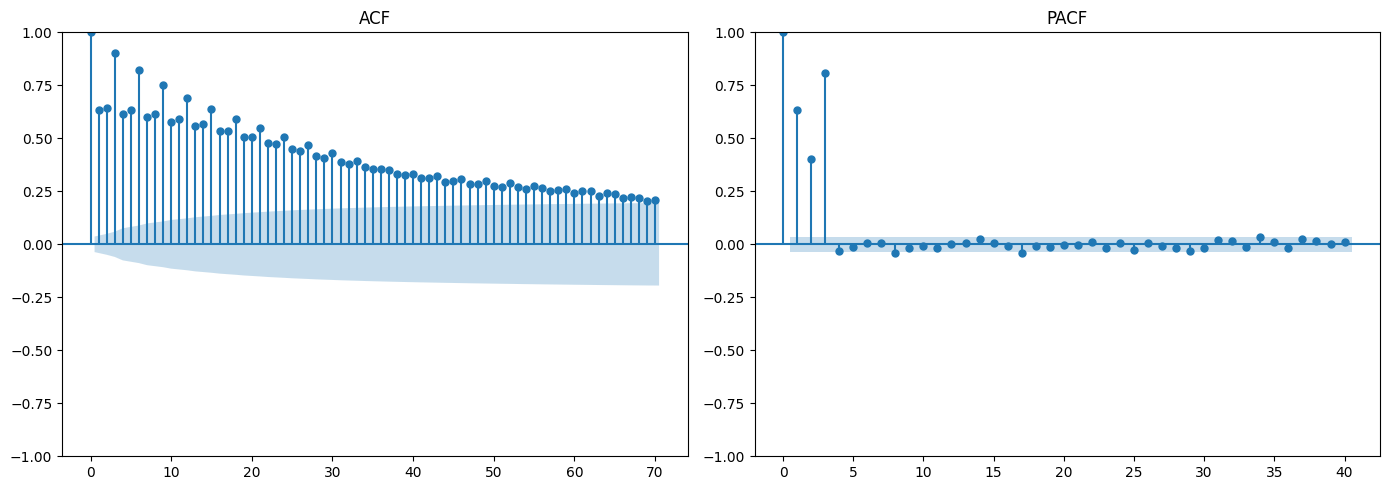

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(fuel_diff, ax=axes[0], lags=70, title="ACF")
plot_pacf(fuel_diff, ax=axes[1], lags=40, title="PACF")
plt.tight_layout()
plt.show()

In [6]:
fuel_diff.index = pd.to_datetime(fuel_diff.index)
fuel_diff = fuel_diff.asfreq('D')  # Set daily frequency explicitly

In [7]:
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA model (p, d, q):
model = ARIMA(fuel_diff, order=(3, 1, 67))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:       Fuel_Consumption   No. Observations:                 2847
Model:                ARIMA(3, 1, 67)   Log Likelihood               -4018.659
Date:                Tue, 21 Jan 2025   AIC                           8179.319
Time:                        09:28:55   BIC                           8602.029
Sample:                    05-25-2008   HQIC                          8331.775
                         - 03-10-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3593      0.079     -4.571      0.000      -0.513      -0.205
ar.L2          0.1474      0.093      1.585      0.113      -0.035       0.330
ar.L3          0.8438      0.073     11.578      0.0

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

true_values = fuel_diff.loc['2015-10-20':'2015-10-20']
# Predicted values (from your model)
predicted_values = model_fit.predict(start='2015-10-20', end='2015-10-20')
# Calculate error
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 0.24


## Frequency to update parameters to save RMSE under 1 liter of water:

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

# Subset data from 2015-10-20
subset_data = fuel_data.loc['2015-10-20':]

# Define update intervals (e.g., every 30, 60, 90 days)
update_intervals = [7 * i for i in range(5, 10)] # Days
results = {}

for interval in update_intervals:
    rmse_list = []
    for i in range(0, len(subset_data), interval):
        chunk = subset_data.iloc[i:i+interval]
        if len(chunk) < 14:  # Ensure at least 2 * period for decomposition
            continue
        try:
            decomposition = seasonal_decompose(chunk['Fuel_Consumption'], model='additive', period=7)
            reconstructed = decomposition.trend + decomposition.seasonal
            reconstructed = reconstructed.dropna()  # Drop NaN values from trend and seasonal
            actual = chunk['Fuel_Consumption'].loc[reconstructed.index]  # Align indices
            rmse = np.sqrt(mean_squared_error(actual, reconstructed))
            rmse_list.append(rmse)
        except ValueError as e:
            print(f"Skipping interval {i}-{i+interval} due to insufficient data.")
    results[interval] = np.mean(rmse_list) if rmse_list else None

print("Average RMSE for each interval:")
print(results)


Average RMSE for each interval:
{35: 0.7186005213702548, 42: 0.7416982376780857, 49: 0.7610407590025213, 56: 0.7927264276680109, 63: 0.7983883981495463}


## Answer: We need to update the parameters of the model every week.

## Plot the graphs of predicted and true values:

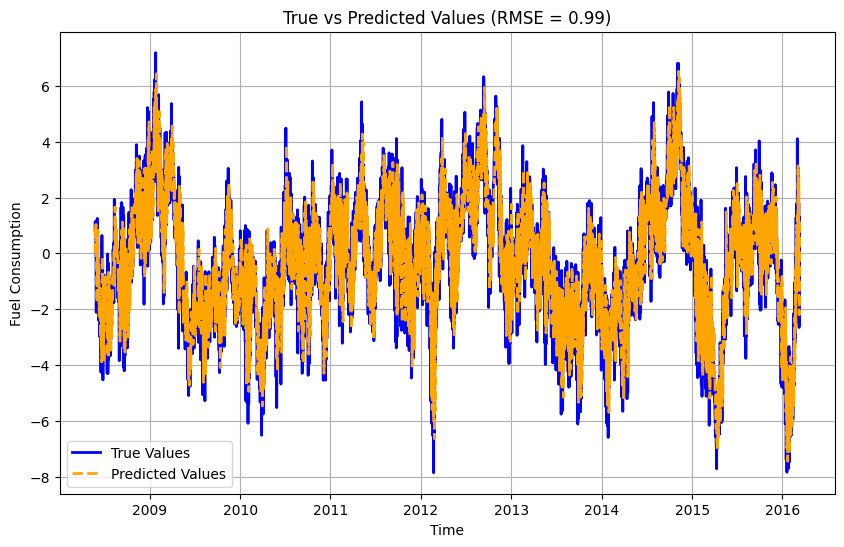

In [10]:
predicted_values = model_fit.predict(start='2008-05-25', end='2016-03-10')
true_values = fuel_diff.loc['2008-05-25':'2016-03-10']
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(true_values, label='True Values', color='blue', linewidth=2)
plt.plot(predicted_values, label='Predicted Values', color='orange', linestyle='--', linewidth=2)
plt.title(f'True vs Predicted Values (RMSE = {rmse:.2f})')
plt.xlabel('Time')
plt.ylabel('Fuel Consumption')
plt.legend()
plt.grid(True)
plt.show()

## BONUS: Online ARIMA:

In this setup, model.update(new_data) updates the model with new data points, and model.predict(n_periods=steps) forecasts future values:

In [13]:
import pmdarima as pm
import numpy as np
import warnings

warnings.filterwarnings("ignore", message="'force_all_finite' was renamed to 'ensure_all_finite'")

# Initialize the Online ARIMA model
model = pm.auto_arima(fuel_diff.loc[:'2016-03-08'], start_p=1, start_q=1, seasonal=True, m=12, stepwise=True, trace=True)

# Function to update the model with new data
def update_model(new_data):
    model.update(new_data)

# Function to make a forecast
def make_forecast(steps=1):
    return model.predict(n_periods=steps)


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=9757.650, Time=6.45 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=12180.751, Time=0.14 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=10998.148, Time=2.36 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=9985.563, Time=4.99 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=12178.752, Time=0.08 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=9781.567, Time=2.41 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=9758.464, Time=3.72 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=9755.879, Time=13.91 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=9756.484, Time=6.16 sec
 ARIMA(1,1,1)(2,0,2)[12] intercept   : AIC=9752.698, Time=27.67 sec
 ARIMA(1,1,1)(1,0,2)[12] intercept   : AIC=9753.017, Time=13.36 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=9952.230, Time=36.61 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=10995.099, Time=19.07 sec
 ARIMA(2,1,1)(2,0,2)[12] intercept   : AIC=8132.733, Time=25.39 sec
 ARIMA(2,

To simulate real-time data updates, you can periodically fetch new data and update the model:


In [ ]:
import time

while True:
    # Update the model with the new data
    update_model(fuel_data.loc['2016-03-08':])
    # Make a forecast
    forecast = make_forecast(steps=1)

In [ ]:
from sklearn.metrics import mean_squared_error

true_val = fuel_data.loc['2016-03-08':]
# Calculate RMSE for previous model
previous_model_rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
# Calculate RMSE for dynamic model
dynamic_model_rmse = np.sqrt(mean_squared_error(true_val, forecast))

print(f"Previous Model RMSE: {previous_model_rmse}")
print(f"Dynamic Model RMSE from 2016-03-08: {dynamic_model_rmse}")
